In [5]:
from wompywompy import plot_alluvial
import pandas as pd
import os
import pandas as pd
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as mcolors 
import seaborn as sns
from sklearn.decomposition import PCA
from statsmodels.stats.multitest import multipletests
from upsetplot import UpSet, from_memberships
from itertools import chain
import scipy.sparse as sp
from ember_py.plots import plot_sample_counts
plt.style.use('default')  

In [6]:
# replace this path with the path for where the downloaded supplement file is located
supplement_file_path = "/home/nikki/Supplementary_data/"

# replace this path with output path
output_path = "/home/nikki/swarna2025_figs/figs/supplemental_figs/"

# Supp Fig 1

Sorting Data with sorting algorithm = neighbornet
Sorting Distance matrix with algorithm neighbornet
Determining Optimal Cycle Start
neighbornet_objective for iteration 0 = 1889100640176441
neighbornet_objective for iteration 1 = 1860861144869572
neighbornet_objective for iteration 2 = 1945382460754052
neighbornet_objective for iteration 3 = 2597881170585232
neighbornet_objective for iteration 4 = 2206752877058020
neighbornet_objective for iteration 5 = 1394064054026883
neighbornet_objective for iteration 6 = 1393799332361405
neighbornet_objective for iteration 7 = 2728859750941537
neighbornet_objective for iteration 8 = 2664601094106095
neighbornet_objective for iteration 9 = 2676127571008309
neighbornet_objective for iteration 10 = 2594187608991103
neighbornet_objective for iteration 11 = 2040193096741879
neighbornet_objective for iteration 12 = 1953847145738650
neighbornet_objective for iteration 13 = 1891301087116245
neighbornet_objective for iteration 14 = 1780773225801940
neighbo

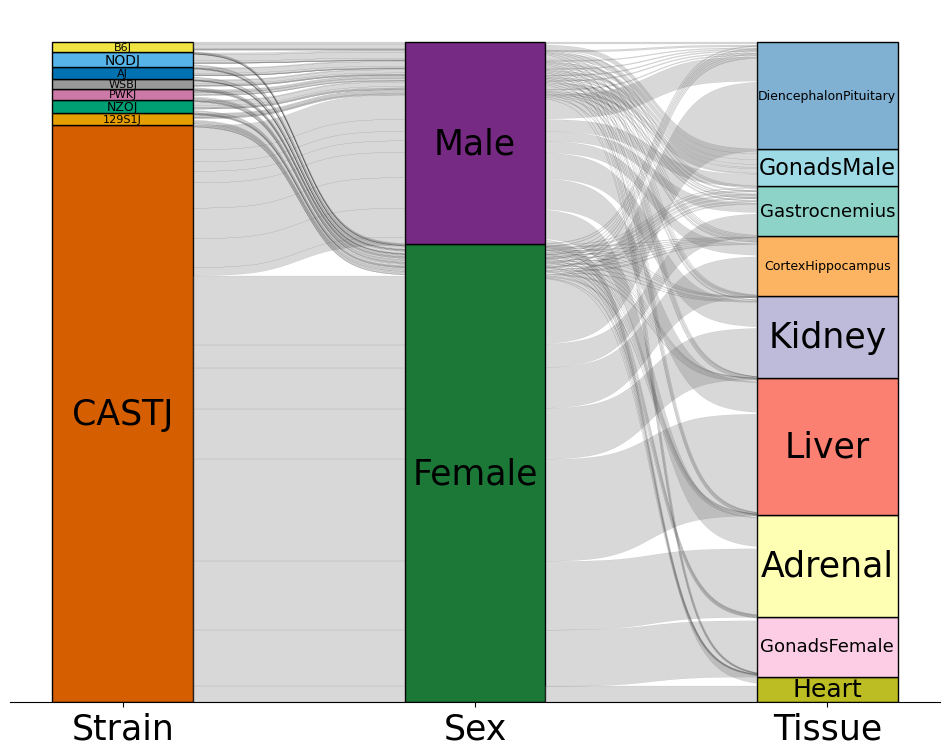

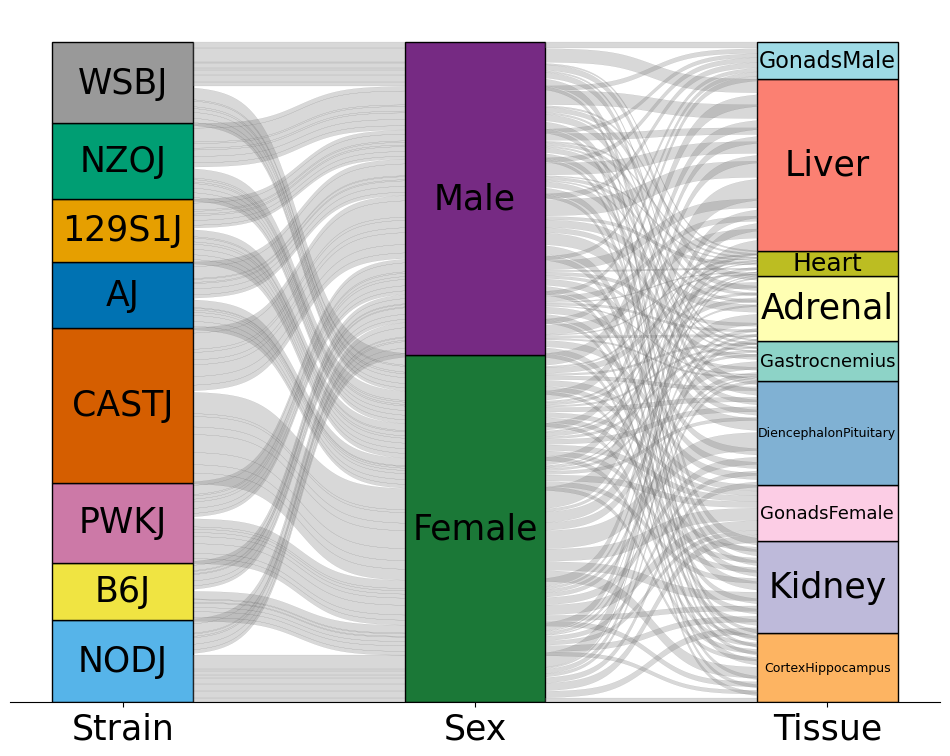

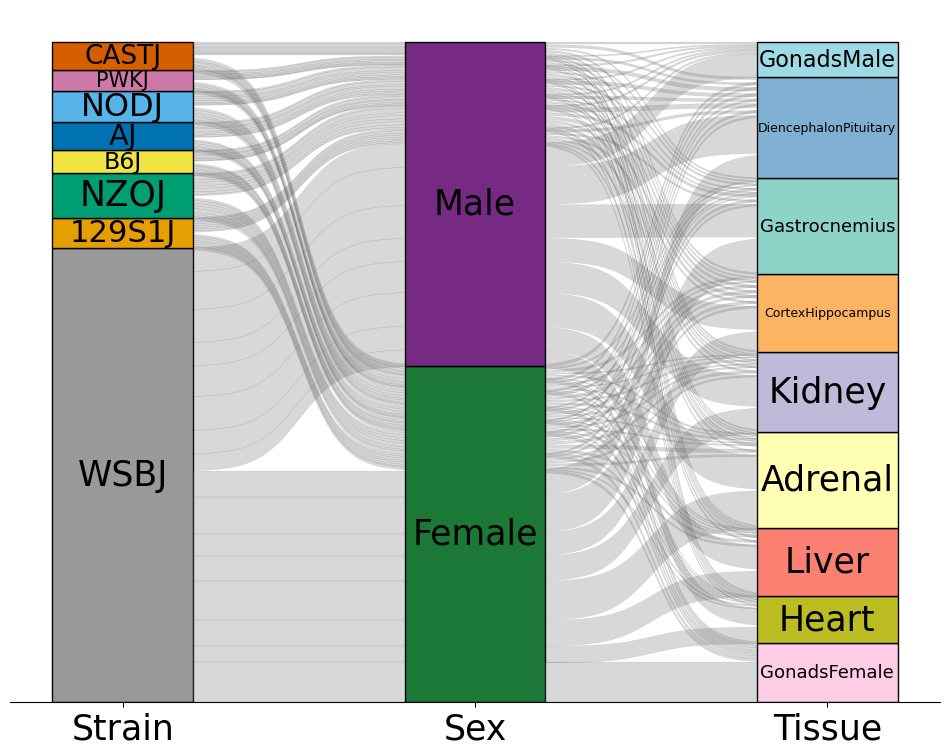

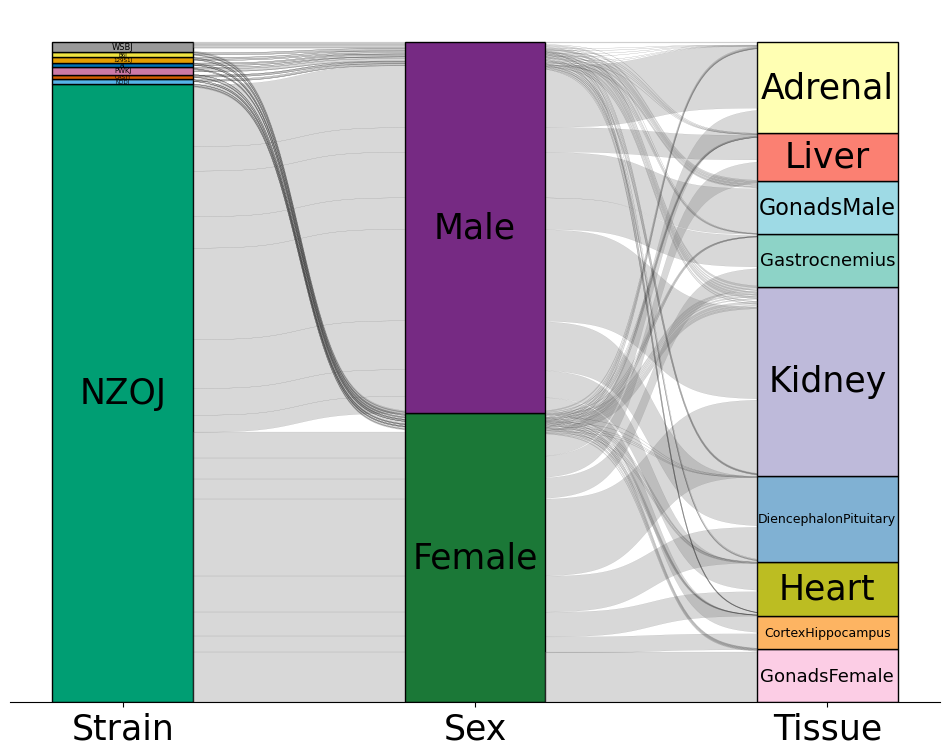

In [7]:
genes = ["Tas1r1", "Zbtb48", "Cwc22", "Gjb4"]

for gene_name in genes:

    df_path = os.path.join(supplement_file_path, f"8cube_across_tissues/{gene_name}_pseudobulk_wompwomp.csv")
    df = pd.read_csv(df_path, index_col = 0)

    # cleaning out empty levels to improve effeciency
    df = df[df['umi_total'] > 0]
    df = df[['Sex', 'Genotype', 'Tissue', 'umi_total']]
    df = df.rename(columns={
        'Genotype': 'Strain'
    })
    df = df.groupby(['Sex', 'Strain', 'Tissue']).agg('sum').reset_index()

    color_dict = {
        "129S1J": "#E69F00",   # orange
        "NODJ": "#56B4E9",     # sky blue
        "NZOJ": "#009E73",     # green
        "B6J": "#F0E442",      # yellow
        "AJ": "#0072B2",       # deep blue
        "CASTJ": "#D55E00",    # vermillion
        "PWKJ": "#CC79A7",     # purple-pink
        "WSBJ": "#999999",      # gray
        "Male": "#762A83",   # violet
        "Female": "#1B7837",      # dark green
        "Gastrocnemius": "#8DD3C7",        # turquoise
        "Adrenal": "#FFFFB3",               # light yellow
        "Kidney": "#BEBADA",              # lavender
        "Liver": "#FB8072",                # coral
        "DiencephalonPituitary": "#80B1D3",# steel blue
        "CortexHippocampus": "#FDB462",           # peach
        "GOnadsMale": "#B3DE69",    # lime green
        "GonadsFemale": "#FCCDE5"          # pink

    }
    fig, order_dict = plot_alluvial(df, #pandas data frame  
                      # general function arguments
                      graphing_columns = ['Strain','Sex', 'Tissue'],optimize_column_order = False, column_weights = 'umi_total',
                                    color_alluvium = False, match_colors = False, verbose = True,
                                    sorting_algorithm = 'neighbornet', return_order_dict = True, color_dict = color_dict,
                                    save_height=12, save_width=9, default_text_size=25, alluvial_alpha=0.3,resolution=30)
    fig[0].savefig(f"/home/nikki/swarna2025_figs/figs/supplemental_figs/{gene_name}_alluvial.png")

# Supp Fig 2

## a

In [8]:
rebboah_pax7_path = os.path.join(supplement_file_path, f"8cube_gastrocnemius/rebboah_pax7.h5ad")
rebboah_pax7 = ad.read_h5ad(rebboah_pax7_path)

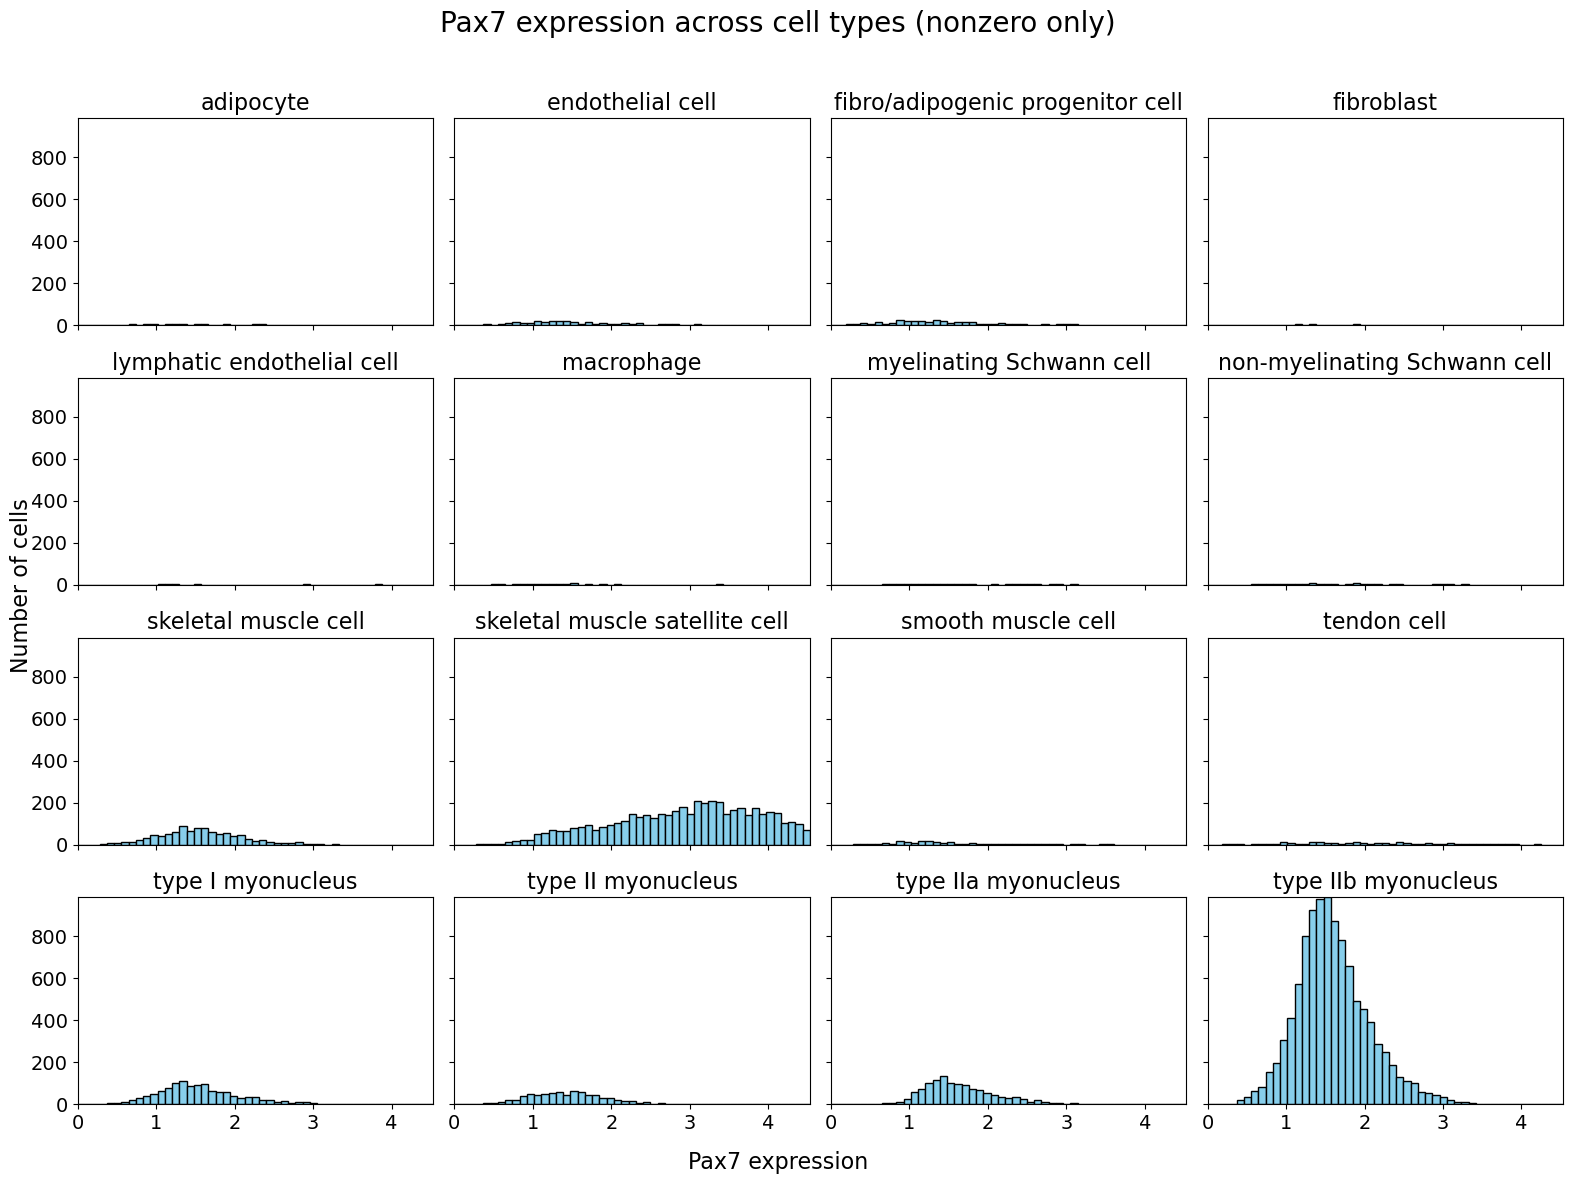

In [9]:
fontsize = 16
gene = "Pax7"
celltype_column = "celltype"

# Get all unique cell types
celltypes = sorted(rebboah_pax7.obs[celltype_column].unique())

# Collect nonzero expression values for each cell type
expression_dict = {}
for celltype in celltypes:
    cell_mask = rebboah_pax7.obs[celltype_column] == celltype
    expression_values = rebboah_pax7[cell_mask, gene].X

    # Convert sparse to dense if needed
    if not isinstance(expression_values, np.ndarray):
        expression_values = expression_values.toarray().flatten()

    # Filter out zeros
    expression_values = expression_values[expression_values > 0]

    expression_dict[celltype] = expression_values

# Determine uniform x and y axis limits
all_values = np.concatenate(list(expression_dict.values()))
x_max = np.percentile(all_values, 99)  # avoid extreme outliers
bins = np.linspace(0, x_max, 50)

# Estimate common y-axis limit
hist_counts = [np.histogram(vals, bins=bins)[0] for vals in expression_dict.values()]
y_max = max([counts.max() for counts in hist_counts])

# Determine grid size for subplots
n = len(celltypes)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

# Plot subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)

for ax, celltype in zip(axes.flat, celltypes):
    values = expression_dict[celltype]
    ax.hist(values, bins=bins, color='skyblue', edgecolor='black')
    ax.set_title(celltype, fontsize=fontsize)
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.tick_params(axis='x', labelsize=fontsize-2)
    ax.tick_params(axis='y', labelsize=fontsize-2)

# Hide unused subplots
for i in range(n, nrows * ncols):
    fig.delaxes(axes.flat[i])

# Add common labels
fig.suptitle(f'{gene} expression across cell types (nonzero only)', fontsize=fontsize+4)
fig.supxlabel(f'{gene} expression', fontsize=fontsize)
fig.supylabel('Number of cells', fontsize=fontsize)
plt.tight_layout(rect=[0, 0, 1, 0.96])
out_fig_path = os.path.join(output_path, "8cube_pax7.png")
plt.savefig(out_fig_path, bbox_inches="tight")
plt.show()


## b

In [10]:
ham_pax7_path = os.path.join(supplement_file_path, f"8cube_gastrocnemius/ham_pax7.h5ad")
ham_pax7 = ad.read_h5ad(ham_pax7_path)

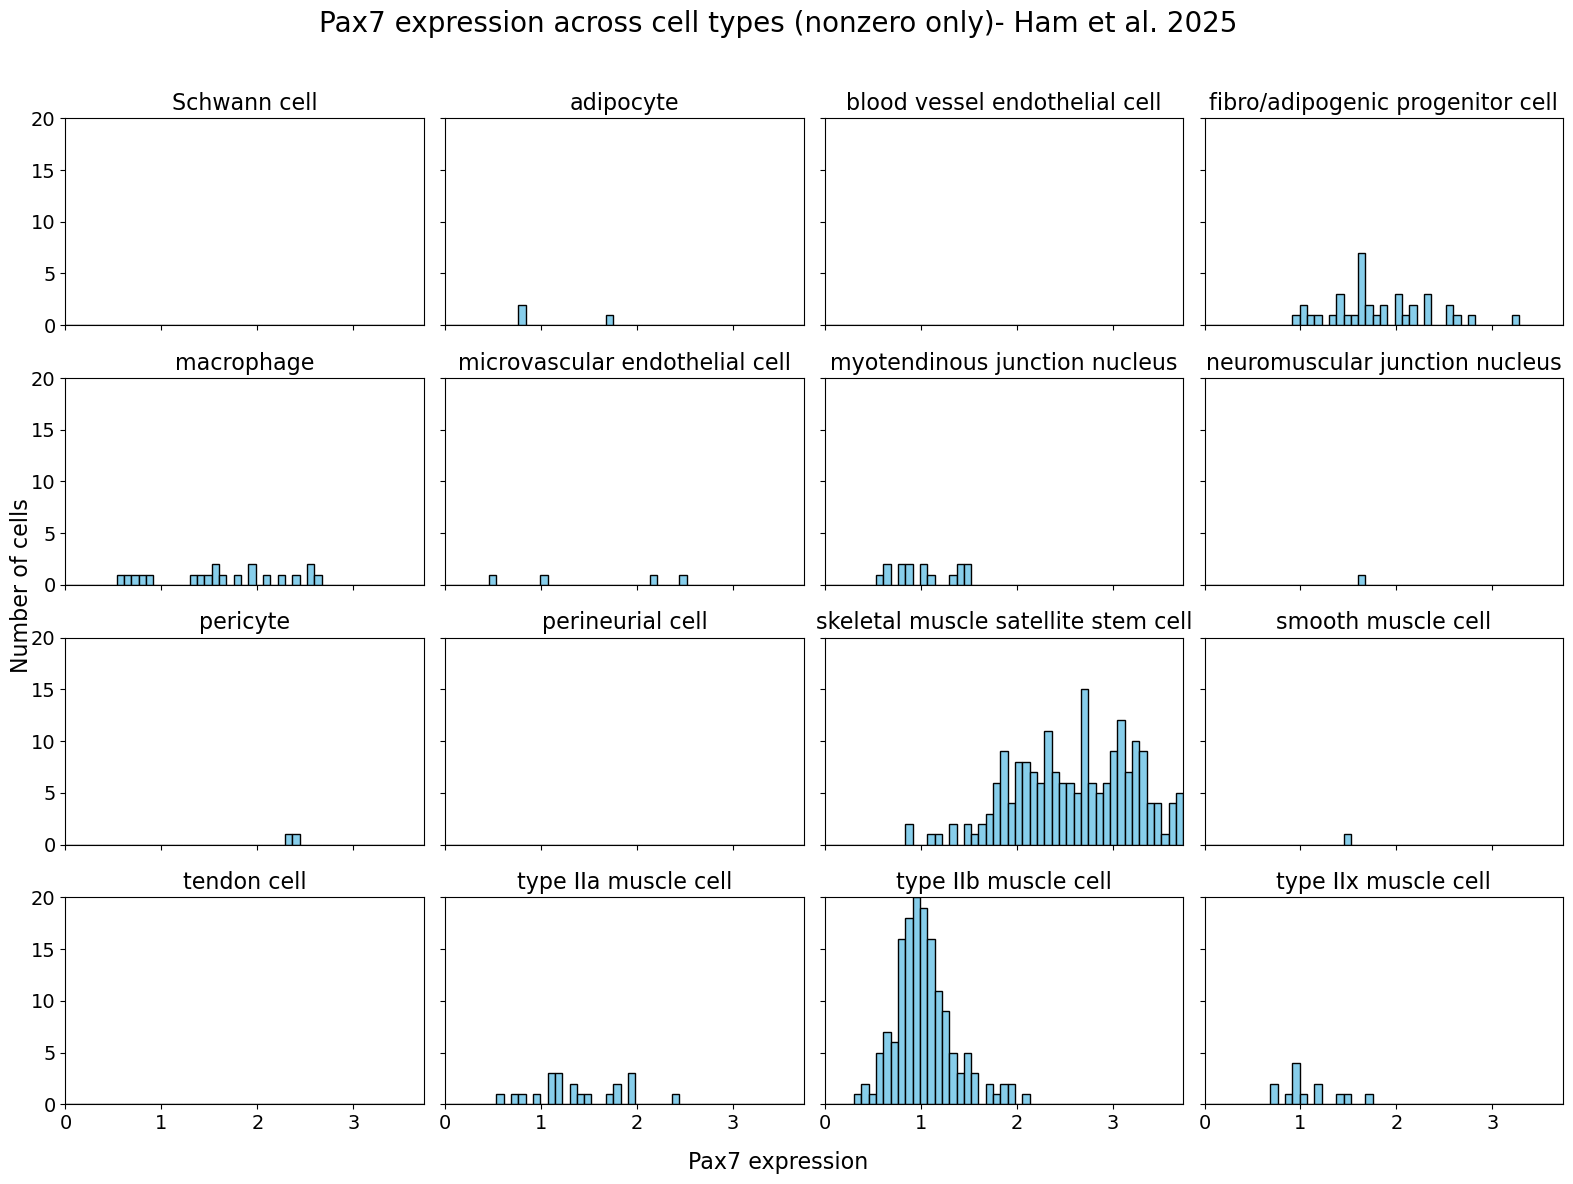

In [11]:
gene = "ENSMUSG00000028736"
celltype_column = "cell_type"
fontsize = 16
# Get all unique cell types
celltypes = sorted(ham_pax7.obs[celltype_column].unique())

# Collect nonzero expression values for each cell type
expression_dict = {}
for celltype in celltypes:
    cell_mask = ham_pax7.obs[celltype_column] == celltype
    expression_values = ham_pax7[cell_mask, gene].X

    # Convert sparse to dense if needed
    if not isinstance(expression_values, np.ndarray):
        expression_values = expression_values.toarray().flatten()

    # Filter out zeros
    expression_values = expression_values[expression_values > 0]

    expression_dict[celltype] = expression_values

# Determine uniform x and y axis limits
all_values = np.concatenate(list(expression_dict.values()))
x_max = np.percentile(all_values, 99)  # avoid extreme outliers
bins = np.linspace(0, x_max, 50)

# Estimate common y-axis limit
hist_counts = [np.histogram(vals, bins=bins)[0] for vals in expression_dict.values()]
y_max = max([counts.max() for counts in hist_counts])

# Determine grid size for subplots
n = len(celltypes)
ncols = int(np.ceil(np.sqrt(n)))
nrows = int(np.ceil(n / ncols))

# Plot subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True, sharey=True)

for ax, celltype in zip(axes.flat, celltypes):
    values = expression_dict[celltype]
    ax.hist(values, bins=bins, color='skyblue', edgecolor='black')
    ax.set_title(celltype, fontsize=fontsize)
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    ax.tick_params(axis='x', labelsize=fontsize-2)
    ax.tick_params(axis='y', labelsize=fontsize-2)

# Hide unused subplots
for i in range(n, nrows * ncols):
    fig.delaxes(axes.flat[i])

# Add common labels
fig.suptitle(f'Pax7 expression across cell types (nonzero only)- Ham et al. 2025', fontsize=fontsize+4)
fig.supxlabel(f'Pax7 expression', fontsize=fontsize)
fig.supylabel('Number of cells', fontsize=fontsize)
out_fig_path = os.path.join(output_path, "Ham_pax7.png")
plt.savefig(out_fig_path, bbox_inches="tight")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# Supp Fig 3

In [12]:
pseudobulk_path = os.path.join(supplement_file_path, "PCA_pseudobulk_expression_matrix_across_tissues_strain.csv")
pseudobulk = pd.read_csv(pseudobulk_path, index_col = 0)

In [13]:
# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pseudobulk.T)

meta = pseudobulk.columns.str.extract(r'(?P<Tissue>.+)_(?P<Genotype>.+)')
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Genotype'] = meta['Genotype'].values
pca_df['Tissue'] = meta['Tissue'].values
pca_df = pca_df.rename(columns={
    'Genotype': 'Strain'
})


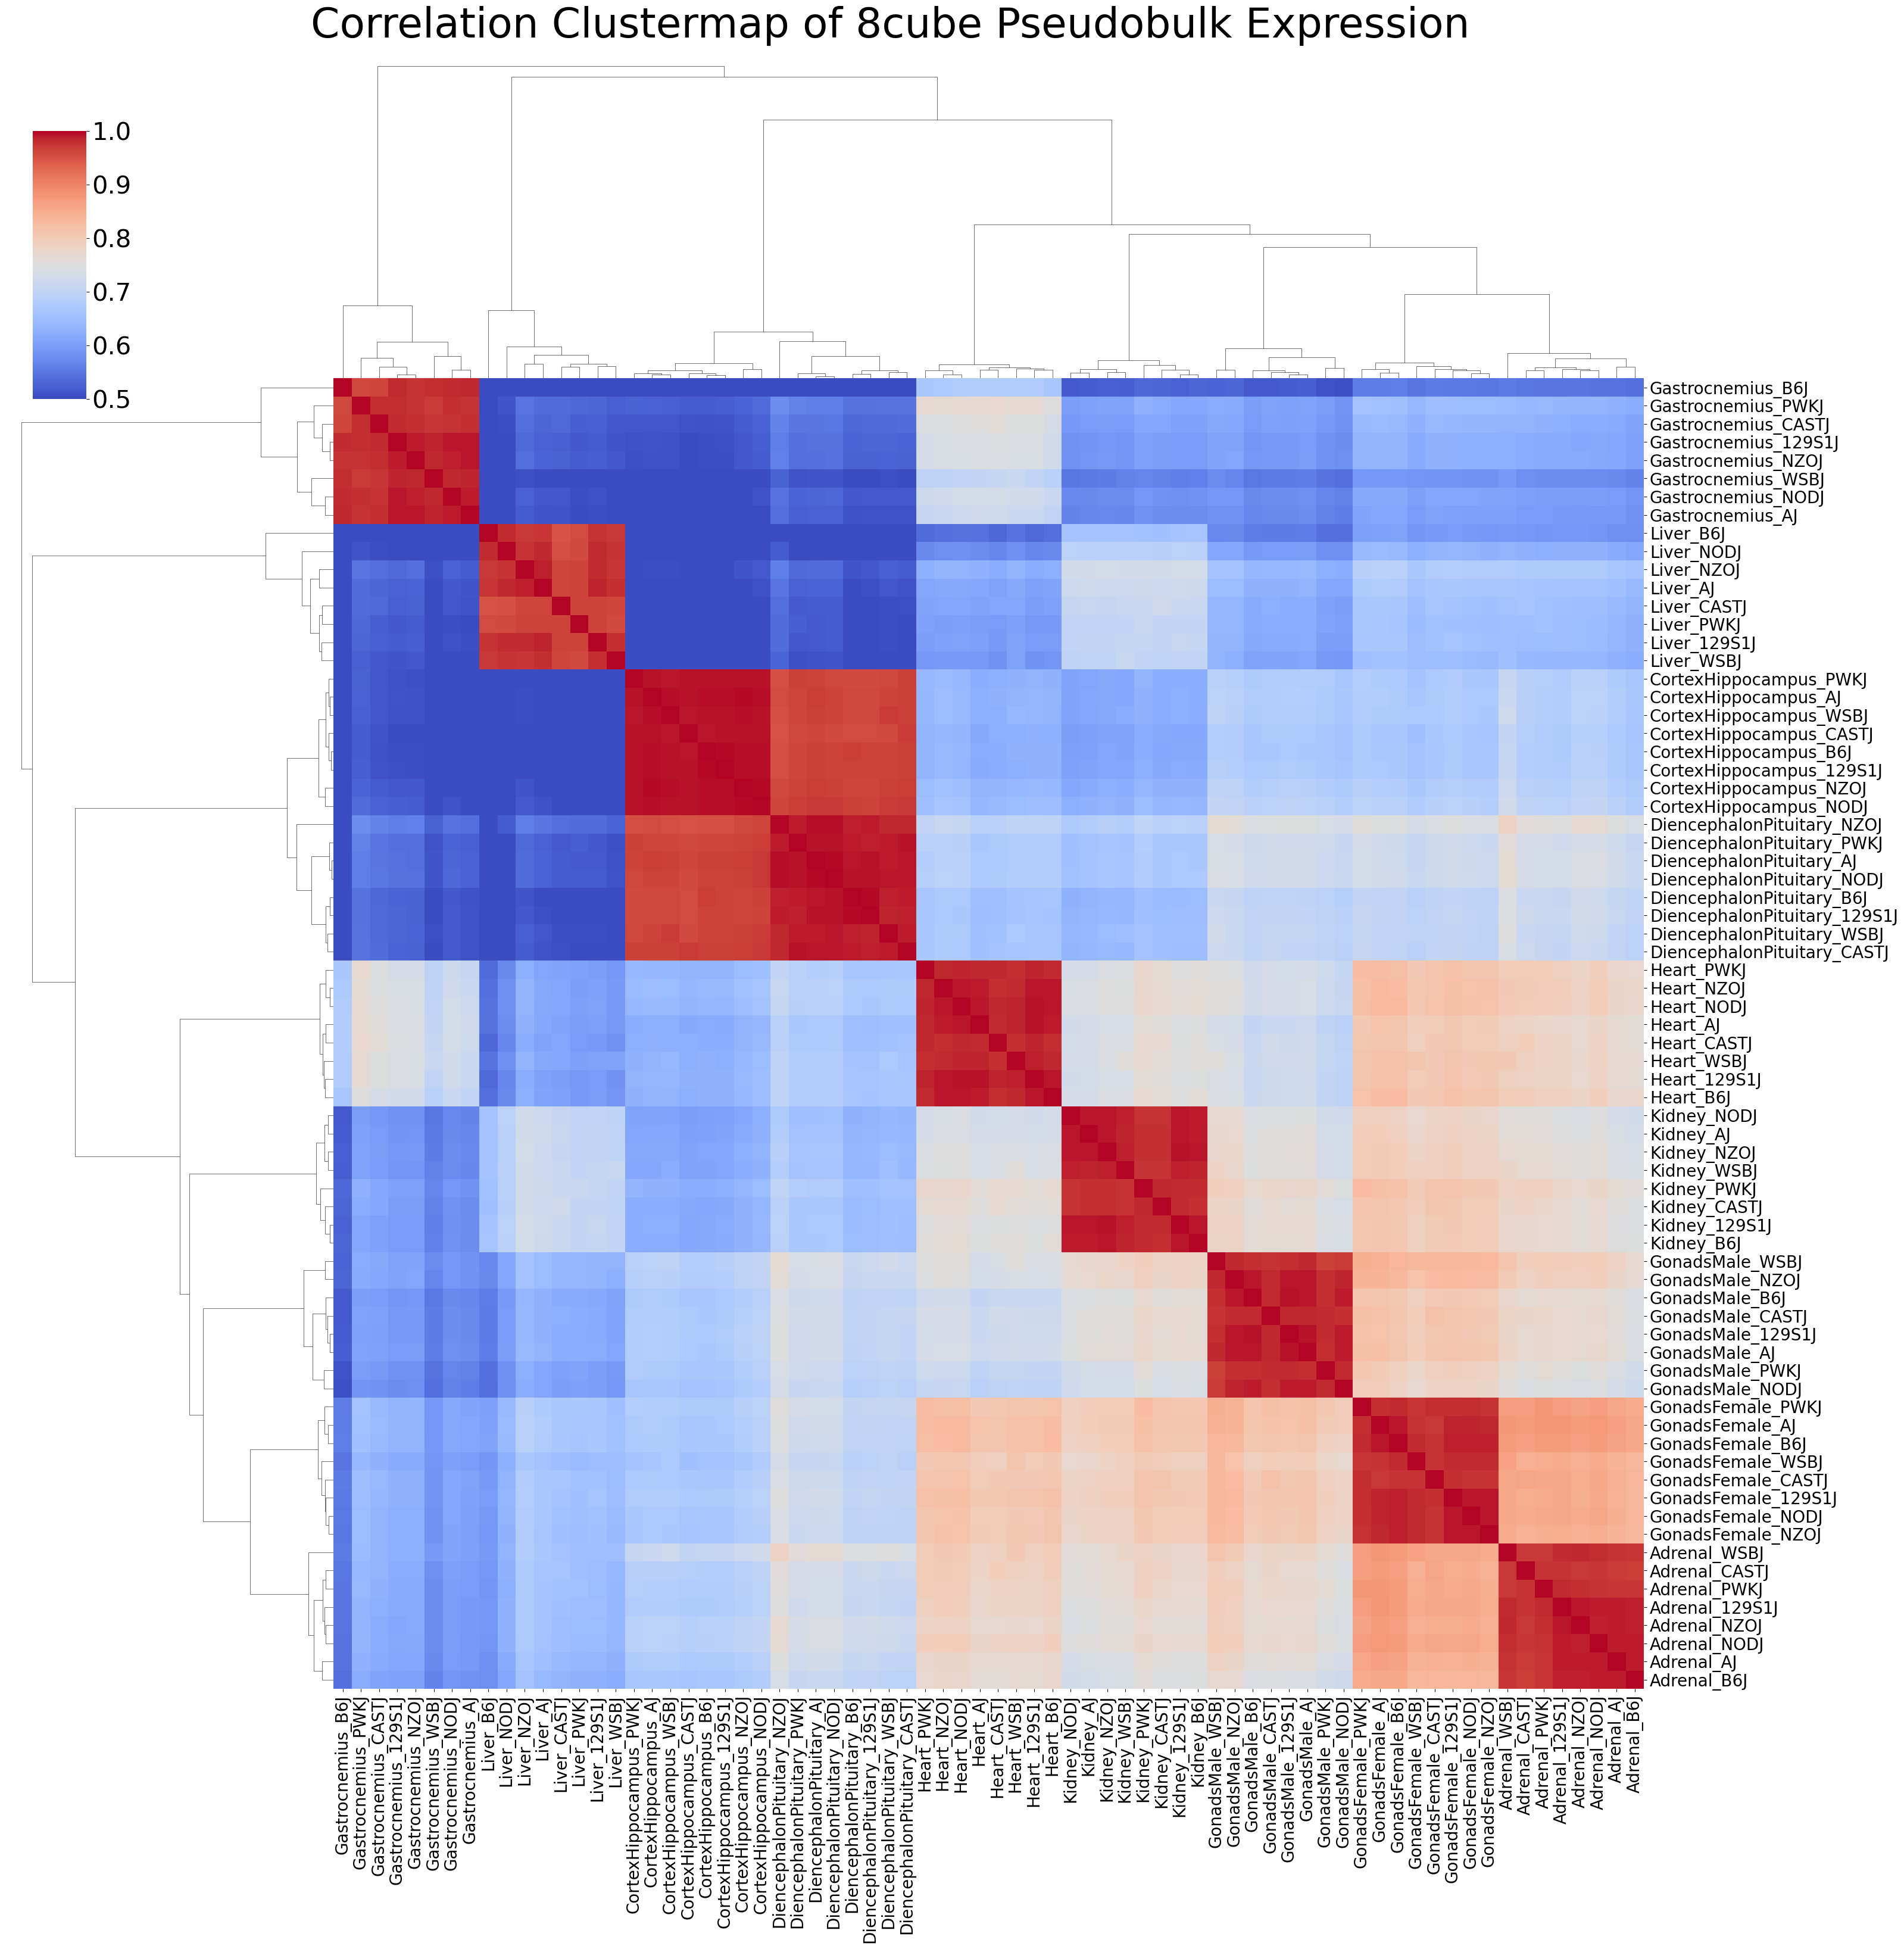

In [14]:
fontsize = 20 


corr_matrix = pseudobulk.corr()

g = sns.clustermap(
    corr_matrix,
    cmap="coolwarm",
    vmin=0.5, vmax=1,
    row_cluster=True, col_cluster=True,
    figsize=(30,30),
    cbar_pos=(0.02, 0.8, 0.03, 0.15) 
)

# Reorder labels if needed
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind
row_labels = [corr_matrix.index[i] for i in row_order]
col_labels = [corr_matrix.columns[i] for i in col_order]

# Apply labels with fontsize
g.ax_heatmap.set_yticklabels(row_labels, fontsize=fontsize, rotation=0)
g.ax_heatmap.set_xticklabels(col_labels, fontsize=fontsize, rotation=90)

# Colorbar tick labels
g.cax.tick_params(labelsize=fontsize+10)

# Title
g.fig.suptitle("Correlation Clustermap of 8cube Pseudobulk Expression", fontsize=fontsize+30, y=1.02)
out_fig_path = os.path.join(output_path, "corr_fig.png")
plt.savefig(out_fig_path, bbox_inches="tight")
plt.show()

# Supp Fig 4

## a

/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.

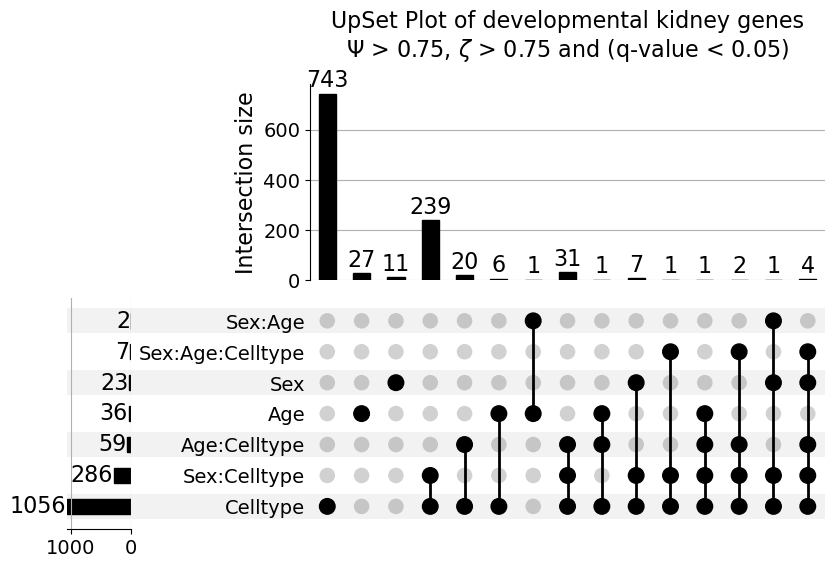

In [15]:
# Define variables
partition_list = ['Sex', 'Celltype', 'Age',
                  'Sex:Celltype', 'Sex:Age', 'Age:Celltype',
                  'Sex:Age:Celltype']
fdr_thresh = 0.05
psi_zeta_thresh = 0.75

# Read all DataFrames and label them by partition
dfs = []
for partition in partition_list:
    pvals_path = os.path.join(supplement_file_path, f"Developmental_kidney/{partition}.csv")
    df = pd.read_csv(pvals_path)
    df['partition'] = partition
    dfs.append(df)

# Combine all data for global FDR correction
combined_df = pd.concat(dfs, ignore_index=True)

# Global FDR correction for both Psi and Zeta
combined_df['Psi p-value'] = combined_df['Psi p-value'].astype(float)
combined_df['Zeta p-value'] = combined_df['Zeta p-value'].astype(float)

_, combined_df['Psi FDR'], _, _ = multipletests(combined_df['Psi p-value'], method='fdr_bh')
_, combined_df['Zeta FDR'], _, _ = multipletests(combined_df['Zeta p-value'], method='fdr_bh')

# Filter for genes significant in both Psi and Zeta, and with effect sizes > 0.5
significant = combined_df[
    (combined_df['Psi FDR'] <= fdr_thresh) &
    (combined_df['Zeta FDR'] <= fdr_thresh) &
    (combined_df['Psi'] > psi_zeta_thresh) &
    (combined_df['Zeta'] > psi_zeta_thresh)
]

# Create sets of significant genes per partition, ensuring no duplicates
partition_gene_sets = {
    partition: set(
        significant[significant['partition'] == partition]['gene_name'].drop_duplicates()
    )
    for partition in partition_list
}


all_genes = set(chain.from_iterable(partition_gene_sets.values()))
memberships = []

for gene in all_genes:
    gene_membership = [
        partition for partition, gene_set in partition_gene_sets.items() if gene in gene_set
    ]
    memberships.append(gene_membership)
    
# Create UpSet data and plot
# Set larger font sizes globally
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title size
    'axes.labelsize': 16,     # axis label size
    'xtick.labelsize': 14,    # x-axis tick labels
    'ytick.labelsize': 14,    # y-axis tick labels
    'legend.fontsize': 14     # legend (if any)
})

upset_data = from_memberships(memberships)

# Create the UpSet plot
UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='degree',
).plot()

# Title and layout
plt.title(
    f'UpSet Plot of developmental kidney genes\n$\Psi$ > {psi_zeta_thresh}, $\zeta$ > {psi_zeta_thresh} and (q-value < {fdr_thresh})',
    pad=20
)
plt.tight_layout()
out_fig_path = os.path.join(output_path, "upset_dev_kidney.png")
plt.savefig(out_fig_path)
plt.show()


## b

In [16]:
pseudobulk_path = os.path.join(supplement_file_path, "PCA_pseudobulk_expression_matrix_kidney_celltype_strain.csv")
pseudobulk = pd.read_csv(pseudobulk_path, index_col = 0)

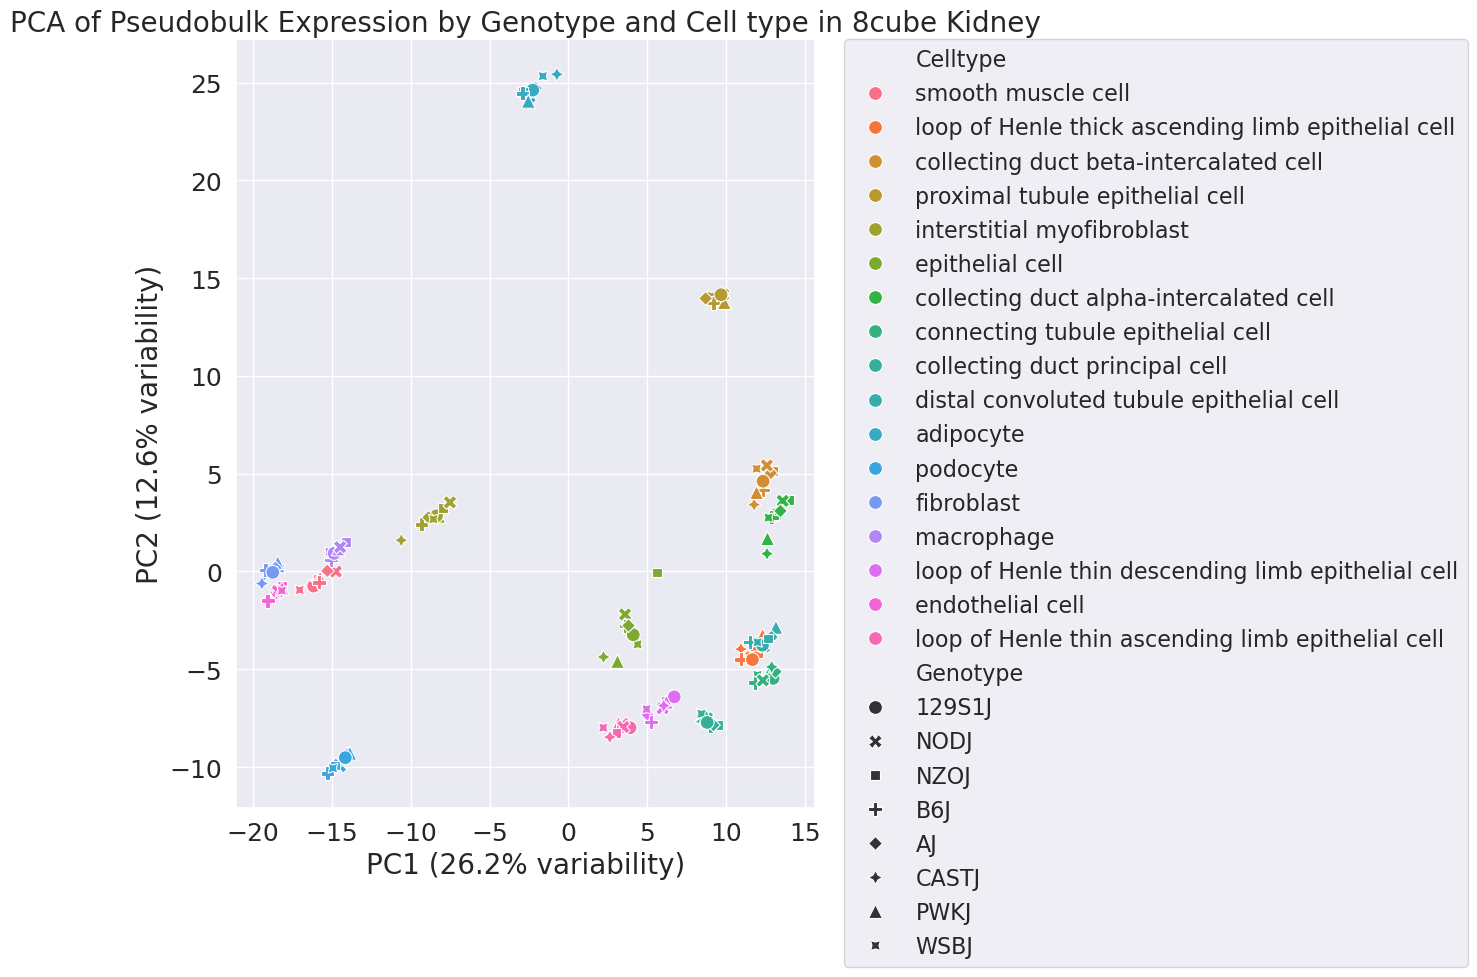

In [17]:
fontsize = 20

pseudobulk.columns

pca = PCA(n_components=2)
pca_result = pca.fit_transform(pseudobulk.T)

meta = pseudobulk.columns.str.extract(r'(?P<Genotype>.+)_(?P<Celltype>.+)')
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Genotype'] = meta['Genotype'].values
pca_df['Celltype'] = meta['Celltype'].values

plt.figure(figsize=(14,10))
sns.set(context='notebook', font_scale=1.2)

ax = sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Celltype',
    style='Genotype',
    s=100
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variability)', fontsize = fontsize)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variability)', fontsize = fontsize)
plt.title("PCA of Pseudobulk Expression by Genotype and Cell type in 8cube Kidney", fontsize = fontsize)

# tick labels fontsize = fontsize-2
plt.xticks(fontsize=fontsize-2)
plt.yticks(fontsize=fontsize-2)

# Move legend to the right side
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0., 
    fontsize = fontsize-4
)

plt.tight_layout()
out_fig_path = os.path.join(output_path, "PCA_kidney_celltype_strain_fig.png")
plt.savefig(out_fig_path)
plt.show()

## c

/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/nikki/miniconda3/envs/swarna2025_env/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.

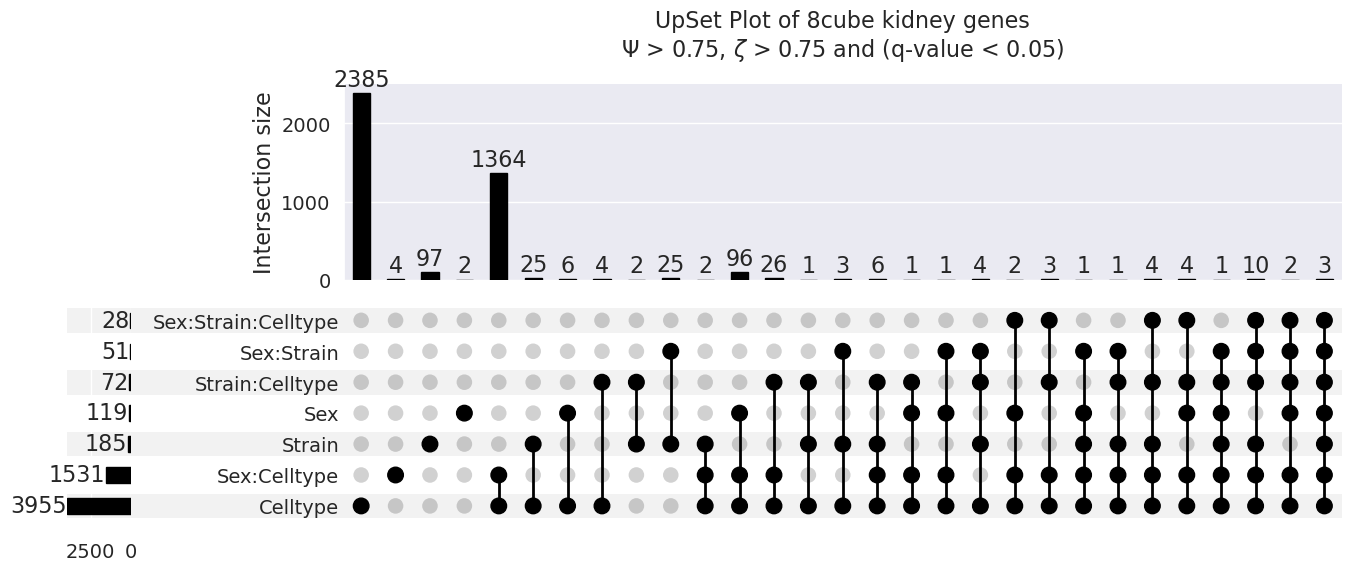

In [18]:
# Define variables
partition_list = ['Sex', 'Celltype', 'Strain',
                  'Sex:Celltype', 'Sex:Strain', 'Strain:Celltype',
                  'Sex:Strain:Celltype']
fdr_thresh = 0.05
psi_thresh = 0.75
zeta_thresh = 0.75

# Read all DataFrames and label them by partition
dfs = []
for partition in partition_list:
    pvals_path = os.path.join(supplement_file_path, f"8cube_kidney/Kidney_{partition}.csv")
    df = pd.read_csv(pvals_path)
    df['partition'] = partition
    dfs.append(df)

# Combine all data for global FDR correction
combined_df = pd.concat(dfs, ignore_index=True)

# Global FDR correction for both Psi and Zeta
_, combined_df['Psi FDR'], _, _ = multipletests(combined_df['Psi p-value'], method='fdr_bh')
_, combined_df['Zeta FDR'], _, _ = multipletests(combined_df['Zeta p-value'], method='fdr_bh')

# Filter for genes significant in both Psi and Zeta, and with effect sizes > 0.5
significant = combined_df[
    (combined_df['Psi FDR'] <= fdr_thresh) &
    (combined_df['Zeta FDR'] <= fdr_thresh) &
    (combined_df['Psi'] > psi_thresh) &
    (combined_df['Zeta'] > zeta_thresh)
]


# Create sets of significant genes per partition, ensuring no duplicates
partition_gene_sets = {
    partition: set(
        significant[significant['partition'] == partition]['gene_name']
    )
    for partition in partition_list
}


all_genes = set(chain.from_iterable(partition_gene_sets.values()))
memberships = []

for gene in all_genes:
    gene_membership = [
        partition for partition, gene_set in partition_gene_sets.items() if gene in gene_set
    ]
    memberships.append(gene_membership)
    
# Create UpSet data and plot
# Set larger font sizes globally
plt.rcParams.update({
    'font.size': 16,          # base font size
    'axes.titlesize': 16,     # title size
    'axes.labelsize': 16,     # axis label size
    'xtick.labelsize': 14,    # x-axis tick labels
    'ytick.labelsize': 14,    # y-axis tick labels
    'legend.fontsize': 14     # legend (if any)
})

upset_data = from_memberships(memberships)

# Create the UpSet plot
UpSet(
    upset_data,
    subset_size='count',
    show_counts=True,
    sort_by='degree',
).plot()

# Title and layout
plt.title(
    f'UpSet Plot of 8cube kidney genes\n$\Psi$ > {psi_thresh}, $\zeta$ > {zeta_thresh} and (q-value < {fdr_thresh})',
    pad=20
)
plt.tight_layout()
out_fig_path = os.path.join(output_path, "upset_8cube_kidney.png")
plt.savefig(out_fig_path)
plt.show()

# Supp Fig 5

## a

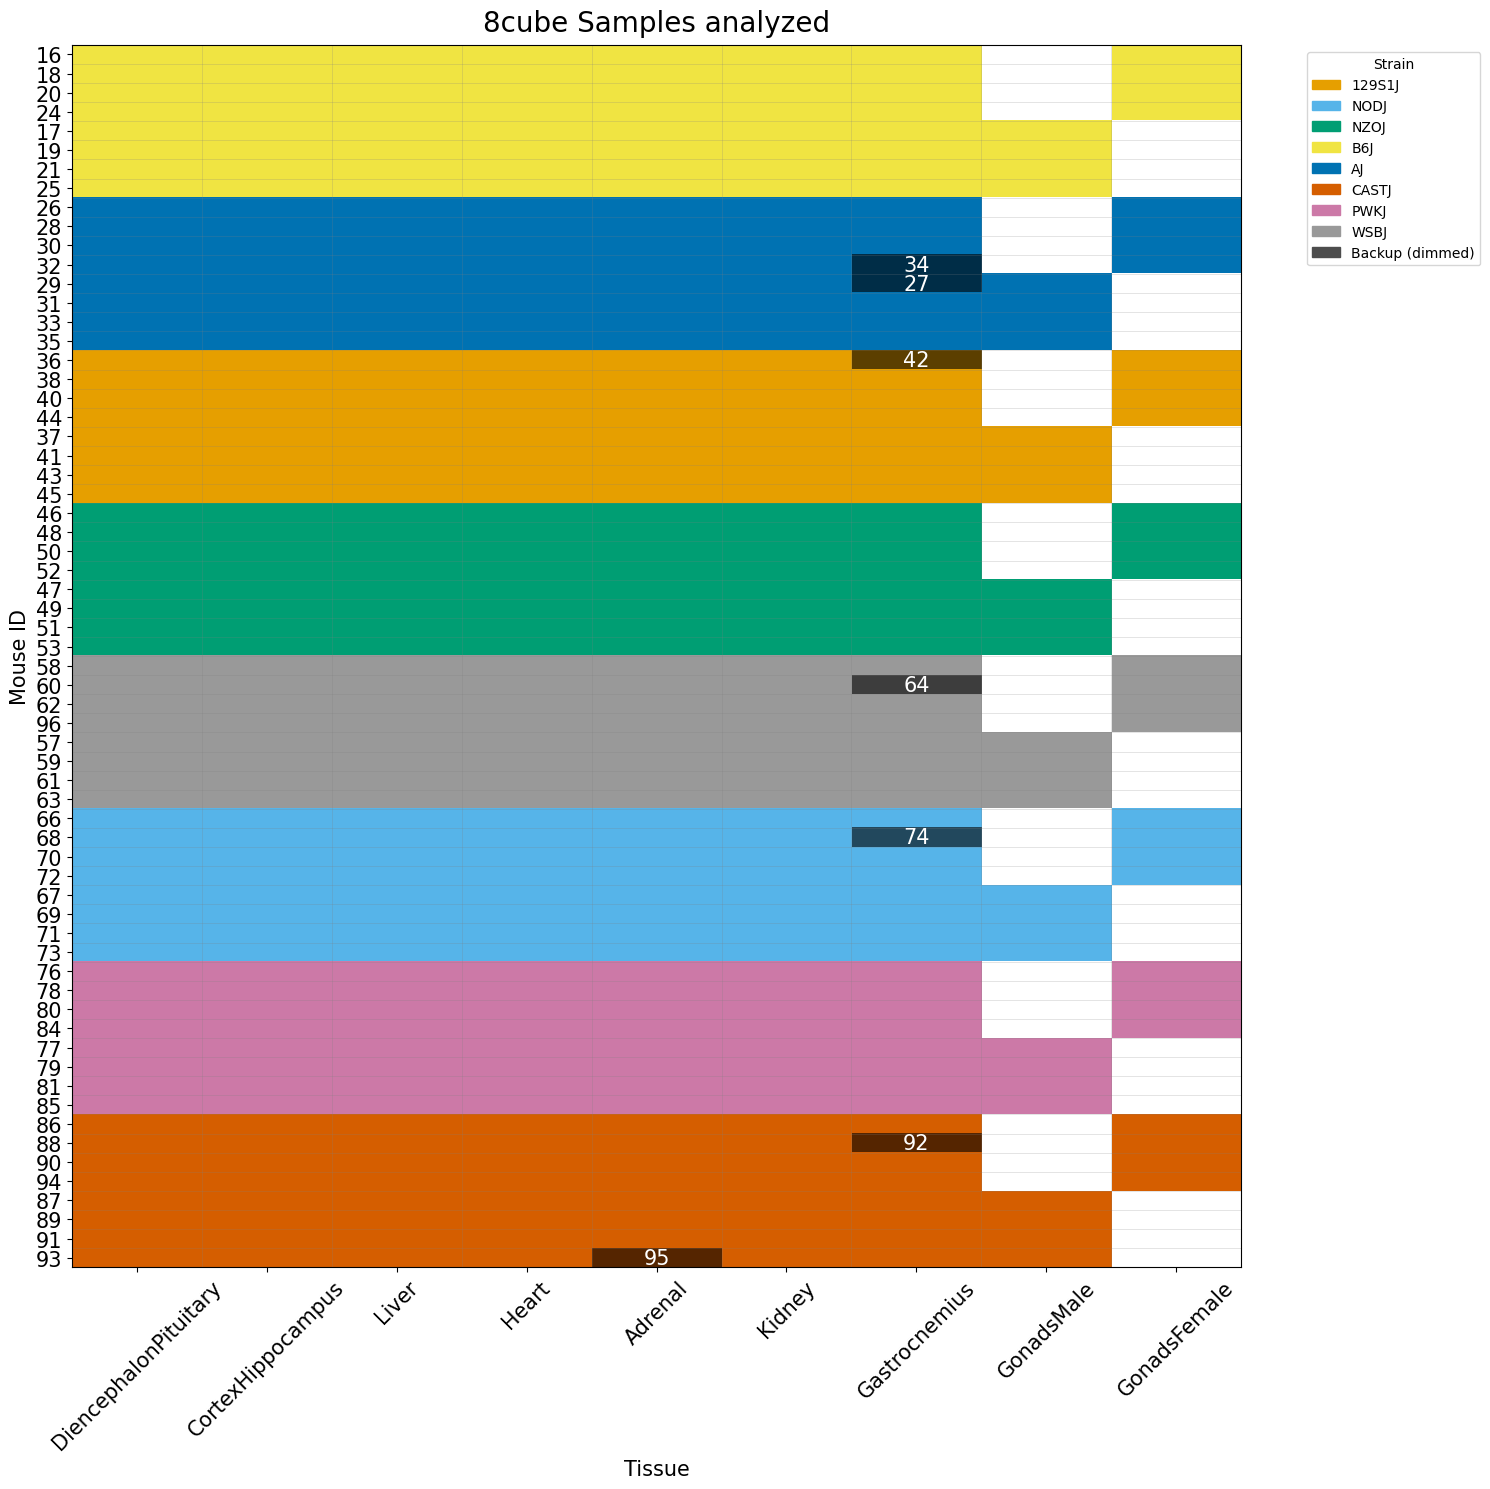

In [32]:
# Read metadata
plt.style.use('default')
df_path = os.path.join(supplement_file_path, "8cube_across_tissues/8cube_metadata.csv")
cleaned_df = pd.read_csv(df_path)

# Create pivot of strain values
strain_df = cleaned_df.pivot_table(index='mouse_id', columns='tissue', values='strain', aggfunc='first')

# Create pivot of is_backup values
backup_df = cleaned_df.pivot_table(index='mouse_id', columns='tissue', values='is_backup', aggfunc='first')

# Create pivot of original_mouse_id values
og_id_df = cleaned_df.pivot_table(index='mouse_id', columns='tissue', values='original_mouse_id', aggfunc='first')

# Ensure consistent tissue column order
ordered_tissues = ['DiencephalonPituitary', 'CortexHippocampus', 'Liver', 'Heart',
                   'Adrenal', 'Kidney', 'Gastrocnemius', 'GonadsMale', 'GonadsFemale']

strain_df = strain_df[ordered_tissues]
backup_df = backup_df[ordered_tissues]
og_id_df = og_id_df.reindex(index=strain_df.index, columns=ordered_tissues)

# Custom strain colors
mice_strains = {
    "129S1J": "#E69F00",
    "NODJ": "#56B4E9",
    "NZOJ": "#009E73",
    "B6J": "#F0E442",
    "AJ": "#0072B2",
    "CASTJ": "#D55E00",
    "PWKJ": "#CC79A7",
    "WSBJ": "#999999"
}

# Identify unique strains
strain_labels = pd.unique(strain_df.values.ravel())
strain_labels = [s for s in strain_labels if pd.notna(s)]
strain_to_color = {strain: mice_strains.get(strain, "#999999") for strain in strain_labels}

# Infer sex from gonadal tissue presence
sex_sort = strain_df.apply(lambda row: 0 if pd.notna(row['GonadsFemale']) else 1, axis=1)

# Sort by strain and sex
strain_order = strain_df['DiencephalonPituitary'].map({s: i for i, s in enumerate(strain_labels)})
ordering_df = pd.DataFrame({'strain_sort': strain_order, 'sex_sort': sex_sort}, index=strain_df.index)
ordered_mouse_ids = ordering_df.sort_values(['strain_sort', 'sex_sort']).index

# Apply sorted order
strain_df = strain_df.loc[ordered_mouse_ids]
backup_df = backup_df.loc[ordered_mouse_ids]
og_id_df = og_id_df.loc[ordered_mouse_ids]

# Build color and annotation grids
colors = []
annotations = []

for i, row in strain_df.iterrows():
    color_row, ann_row = [], []
    for j, strain in enumerate(row):
        tissue = strain_df.columns[j]
        if pd.isna(strain):
            color = (1, 1, 1)
            ann = ""
        else:
            base_rgb = np.array(mcolors.to_rgb(strain_to_color[strain])) 
            is_backup = backup_df.loc[i, tissue]
            og_id = og_id_df.loc[i, tissue]
            if is_backup:
                color = tuple(base_rgb * 0.4)
                if pd.notna(og_id):
                    if isinstance(og_id, float) and og_id.is_integer():
                        ann = str(int(og_id))
                    else:
                        ann = str(og_id)
                else:
                    ann = ""

            else:
                color = base_rgb
                ann = ""
        color_row.append(color)
        ann_row.append(ann)
    colors.append(color_row)
    annotations.append(ann_row)

colors = np.array(colors)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(15, 15))
fontsize = 15
ax.imshow(colors, aspect='auto')

# Add annotations
for i in range(len(annotations)):
    for j in range(len(annotations[0])):
        if annotations[i][j]:
            ax.text(j, i, annotations[i][j], ha='center', va='center', fontsize=fontsize, color='white')

# Axis labels
ax.set_xticks(np.arange(strain_df.shape[1]))
ax.set_xticklabels(strain_df.columns, rotation=45, fontsize=fontsize)
ax.set_yticks(np.arange(strain_df.shape[0]))
ax.set_yticklabels(strain_df.index, fontsize=fontsize)

# Titles and labels
ax.set_title("8cube Samples analyzed", fontsize=fontsize+5, pad=10)
ax.set_xlabel("Tissue", fontsize=fontsize)
ax.set_ylabel("Mouse ID", fontsize=fontsize)

# Legend using your mice_strains colors
legend_handles = [Patch(color=color, label=strain) for strain, color in mice_strains.items()]
legend_handles.append(Patch(color=(0.3, 0.3, 0.3), label="Backup (dimmed)"))
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', title="Strain")

# Grid lines
ax.set_xticks(np.arange(strain_df.shape[1]+1) - 0.5, minor=True)
ax.set_yticks(np.arange(strain_df.shape[0]+1) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5, alpha=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
out_fig_path = os.path.join(output_path, "8cube_summary_plot.png")
plt.savefig(out_fig_path)
plt.show()


## b

In [26]:
adata_path = os.path.join(supplement_file_path, "Developmental_kidney/Dev_kidney_fig_2_3_genes.h5ad")

Plot saved to /home/nikki/swarna2025_figs/figs/supplemental_figs/summary_barplot.png


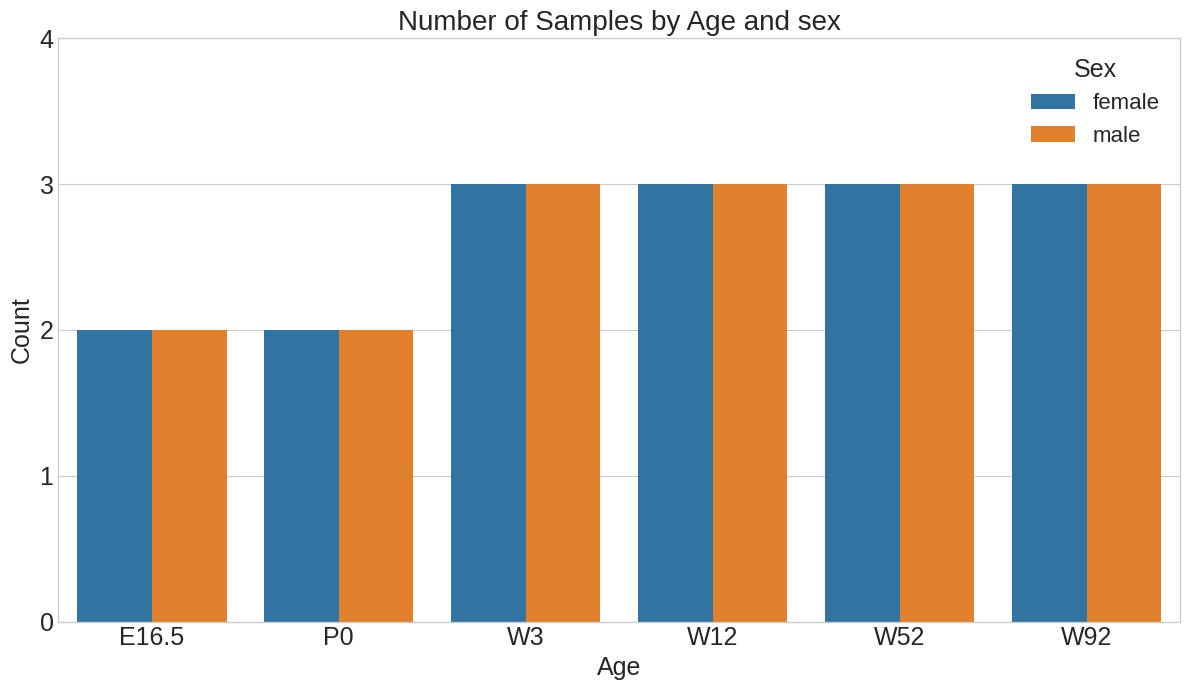

In [27]:
plt.style.use('default')
plot_sample_counts(adata_path, output_path, 'sample_id', "Age", "sex")

## c

In [28]:
adata_path = os.path.join(supplement_file_path, "Human_PBMC/metadata.h5ad")

Plot saved to /home/nikki/swarna2025_figs/figs/supplemental_figs/summary_barplot.png


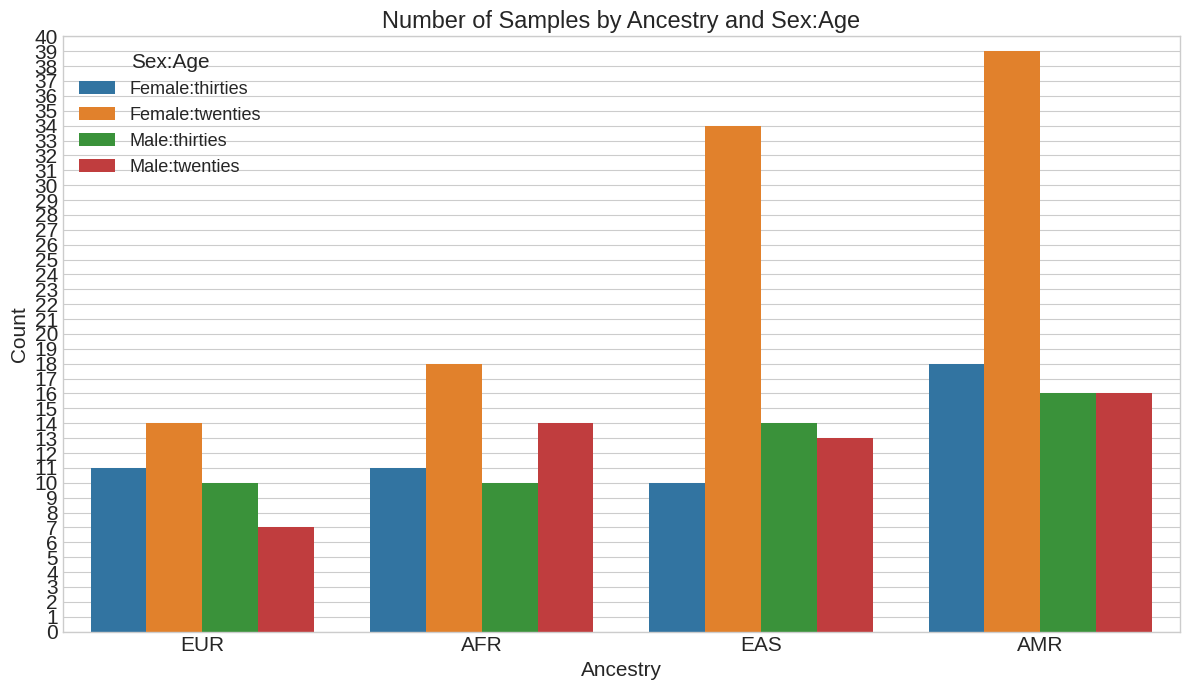

In [29]:
plt.style.use('default')
plot_sample_counts(adata_path, output_path, 'VCF_ID', "Ancestry", "Sex:Age", fontsize = 15)